# Wolff vs. Metropolis: Algorithmic Efficiency in the Critical Regime

Near a second-order phase transition, standard Metropolis–Hastings [[1]](#Bibliography) suffers from *critical slowing down*: the integrated autocorrelation time $\tau_{\mathrm{int}}$ grows as $\tau_{\mathrm{int}} \sim L^z$, with a dynamic critical exponent $z \approx 2.17$ for the 2D Ising model. Physically, successive spin configurations generated by single-site flips remain highly correlated for many steps because proposed flips within a large correlated domain are overwhelmingly rejected and the system cannot efficiently cross free-energy barriers by small local moves.

The Wolff cluster algorithm [[2]](#Bibliography) eliminates this bottleneck directly. Rather than proposing a single-spin flip, Wolff grows a cluster from a random seed by probabilistically bonding same-sign nearest neighbours with probability $P_{\mathrm{add}} = 1 - e^{-2\beta J}$, then flips the entire cluster in one accepted collective move. The bond probability is derived from the Fortuin–Kasteleyn random-cluster representation [[3]](#Bibliography) and guarantees detailed balance without any rejections. The dynamic critical exponent drops to $z \approx 0.25$, nearly an order of magnitude smaller than Metropolis.

The practical benefit is regime-dependent. Far below $T_c$ the equilibrium state is a single near-spanning ferromagnetic domain; all grown clusters are system-spanning and flipping them merely reverses the global magnetisation without decorrelating the configuration. Far above $T_c$ the correlation length is short and clusters are vanishingly small, so the BFS overhead dominates. The Wolff advantage is concentrated in the window $|T - T_c| \lesssim 0.2\,T_c$ where $\xi$ is large but finite. For a comprehensive review of these methods, see Newman and Barkema [[4]](#Bibliography).

This notebook quantifies the crossover using the **independent samples per second** rate, $\mathrm{ISS} = (\text{steps}/\text{s})/\tau_{\mathrm{int}}$, which is the correct figure of merit for equilibrium sampling because it accounts simultaneously for both decorrelation efficiency and raw throughput.


In [ ]:
from __future__ import annotations

import os
import time

import matplotlib.pyplot as plt
import numpy as np

TC_ISING: float = 2.0 / np.log(1.0 + np.sqrt(2.0))
PALETTE = {'metro': '#4878CF', 'wolff': '#D65F5F'}

print(f'Exact Onsager T_c = {TC_ISING:.6f}')

Exact Onsager T_c = 2.269185


## Load or compute data

If a pre-computed `.npz` file from `scripts/ising/wolff_efficiency.py` is available it is loaded directly — no re-run needed. Otherwise a quick inline computation on a small lattice ($L = 16$, 8 temperature points) runs sequentially so the notebook remains fully self-contained. For publication-quality results run the script first:

```bash
python scripts/ising/wolff_efficiency.py --size 64 --meas-steps 2000
```


In [ ]:
NPZ_PATH = '../results/ising/wolff_efficiency.npz'

if os.path.exists(NPZ_PATH):
    data = np.load(NPZ_PATH)
    temperatures      = data['temperatures']
    tau_metro         = data['tau_metro']
    tau_wolff         = data['tau_wolff']
    iss_metro         = data['iss_metro']
    iss_wolff         = data['iss_wolff']
    mean_cluster_frac = data['mean_cluster_frac']
    chi_metro         = data['chi_metro']
    chi_wolff         = data['chi_wolff']
    L = int(data['L'])
    print(f'Loaded pre-computed data: L={L}, {len(temperatures)} temperature points.')

else:
    print('Pre-computed data not found. Running inline demo (L=16, 8 T-points, ~1–2 min)...')
    from models.ising_model import IsingSimulation
    from utils.physics_helpers import calculate_autocorr, calculate_thermodynamics
    from utils.system_helpers import adaptive_equilibrate

    L = 16
    temperatures = np.linspace(1.8, 3.2, 8)
    EQ, MEAS = 200, 500
    results_list = []

    for i, T in enumerate(temperatures):
        # -- Metropolis --
        sim_m = IsingSimulation(size=L, temp=T, update='checkerboard', seed=i * 100)
        adaptive_equilibrate(sim_m, min_steps=EQ)
        t0 = time.perf_counter()
        mags_m, engs_m = sim_m.run(n_steps=MEAS)
        t_m = time.perf_counter() - t0
        mags_m_a = np.array(mags_m)
        try:
            _, tau_m = calculate_autocorr(time_series=mags_m_a)
        except ValueError:
            tau_m = float('nan')
        _, _, chi_m, _ = calculate_thermodynamics(
            mags=mags_m_a, engs=np.array(engs_m), T=T, L=L,
        )
        iss_m = (MEAS / t_m) / tau_m if np.isfinite(tau_m) and tau_m > 0 else float('nan')

        # -- Wolff --
        sim_w = IsingSimulation(size=L, temp=T, update='wolff', seed=i * 100 + 1)
        adaptive_equilibrate(sim_w, min_steps=EQ)
        t0 = time.perf_counter()
        mags_w, engs_w = sim_w.run(n_steps=MEAS)
        t_w = time.perf_counter() - t0
        mags_w_a = np.array(mags_w)
        try:
            _, tau_w = calculate_autocorr(time_series=mags_w_a)
        except ValueError:
            tau_w = float('nan')
        _, _, chi_w, _ = calculate_thermodynamics(
            mags=mags_w_a, engs=np.array(engs_w), T=T, L=L,
        )
        iss_w = (MEAS / t_w) / tau_w if np.isfinite(tau_w) and tau_w > 0 else float('nan')

        # -- Cluster sizes --
        sim_c = IsingSimulation(size=L, temp=T, update='wolff', seed=i * 100 + 2)
        sim_c.equilibrate(n_steps=EQ)
        csizes = []
        for _ in range(100):
            assert sim_c.spins is not None
            s_prev = sim_c.spins.copy()
            sim_c.step()
            assert sim_c.spins is not None
            csizes.append(int(np.sum(sim_c.spins != s_prev)))

        results_list.append({
            'tau_metro': tau_m, 'tau_wolff': tau_w,
            'iss_metro': iss_m, 'iss_wolff': iss_w,
            'mean_cluster_frac': float(np.mean(csizes)) / (L * L),
            'chi_metro': chi_m, 'chi_wolff': chi_w,
        })
        print(f'  T={T:.2f}  tau_metro={tau_m:.1f}  tau_wolff={tau_w:.1f}', flush=True)

    tau_metro         = np.array([r['tau_metro'] for r in results_list])
    tau_wolff         = np.array([r['tau_wolff'] for r in results_list])
    iss_metro         = np.array([r['iss_metro'] for r in results_list])
    iss_wolff         = np.array([r['iss_wolff'] for r in results_list])
    mean_cluster_frac = np.array([r['mean_cluster_frac'] for r in results_list])
    chi_metro         = np.array([r['chi_metro'] for r in results_list])
    chi_wolff         = np.array([r['chi_wolff'] for r in results_list])
    print('Done.')

Loaded pre-computed data: L=64, 20 temperature points.


## Four-panel overview

The top-left panel shows $\tau_{\mathrm{int}}(T)$ on a log scale. Metropolis diverges sharply at $T_c$; Wolff remains nearly flat across the entire range. The top-right panel converts this into the practical metric ISS, showing where Wolff actually wins. The bottom-left panel displays the mean cluster size fraction $\langle C \rangle/N^2$ — the mechanism behind Wolff's advantage. Moving towards $T_c$ from either side, clusters grow to match the diverging correlation length, and each accepted flip decorrelates a macroscopic fraction of the lattice at once. The bottom-right panel confirms that both algorithms converge to the same susceptibility peak, validating that Wolff correctly samples the Boltzmann distribution.


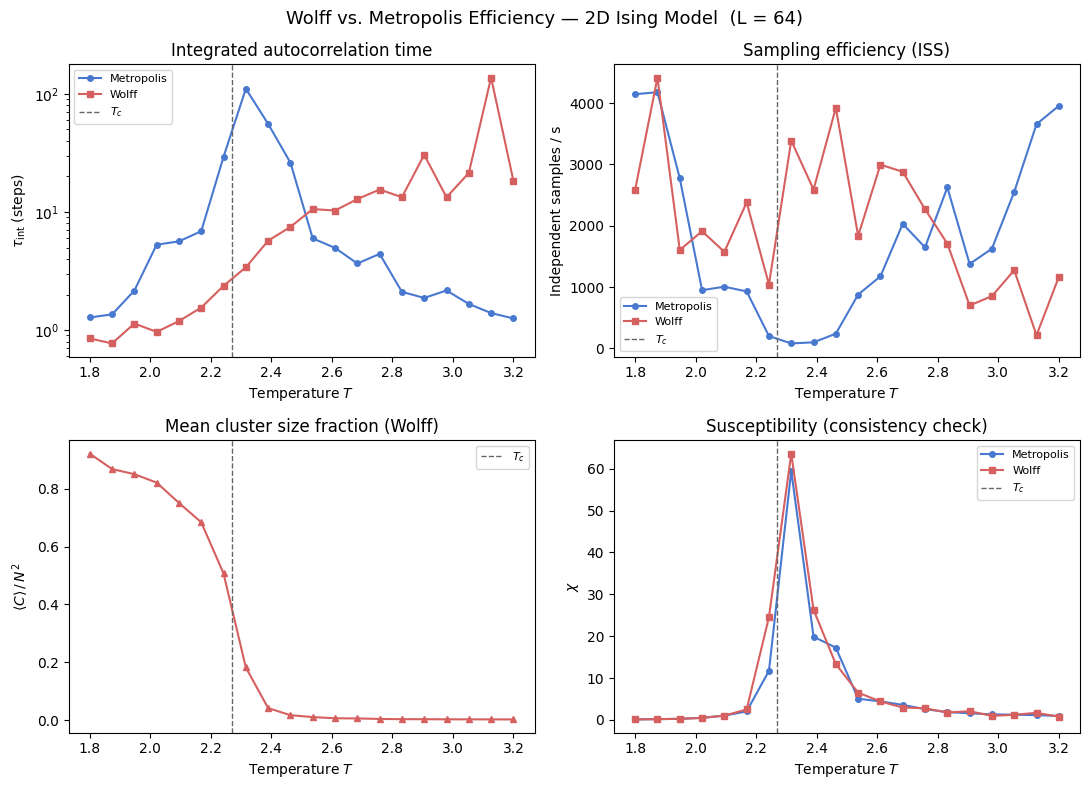

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(
    f'Wolff vs. Metropolis Efficiency — 2D Ising Model  (L = {L})', fontsize=13,
)

# tau_int(T)
ax = axes[0, 0]
ax.semilogy(temperatures, tau_metro, '-o', color=PALETTE['metro'], ms=4, label='Metropolis')
ax.semilogy(temperatures, tau_wolff,  '-s', color=PALETTE['wolff'],  ms=4, label='Wolff')
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$'); ax.set_ylabel(r'$\tau_{\mathrm{int}}$ (steps)')
ax.set_title('Integrated autocorrelation time'); ax.legend(fontsize=8)

# ISS(T)
ax = axes[0, 1]
ax.plot(temperatures, iss_metro, '-o', color=PALETTE['metro'], ms=4, label='Metropolis')
ax.plot(temperatures, iss_wolff,  '-s', color=PALETTE['wolff'],  ms=4, label='Wolff')
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$'); ax.set_ylabel('Independent samples / s')
ax.set_title('Sampling efficiency (ISS)'); ax.legend(fontsize=8)

# mean cluster size fraction
ax = axes[1, 0]
ax.plot(temperatures, mean_cluster_frac, '-^', color=PALETTE['wolff'], ms=4)
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$'); ax.set_ylabel(r'$\langle C \rangle \,/\, N^2$')
ax.set_title('Mean cluster size fraction (Wolff)'); ax.legend(fontsize=8)

# chi consistency
ax = axes[1, 1]
ax.plot(temperatures, chi_metro, '-o', color=PALETTE['metro'], ms=4, label='Metropolis')
ax.plot(temperatures, chi_wolff,  '-s', color=PALETTE['wolff'],  ms=4, label='Wolff')
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$'); ax.set_ylabel(r'$\chi$')
ax.set_title(r'Susceptibility (consistency check)'); ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

The four panels establish the empirical pattern: $\tau_\mathrm{int}$ under Wolff is suppressed near $T_c$ while the Metropolis value diverges, and the ISS ratio in the bottom-right translates that gap into a concrete sampling advantage. The section below explains the statistical mechanics behind the suppression.


## The mechanism: correlated clusters and the FK representation

The connection between cluster size and decorrelation efficiency is quantitative. In the FK representation, activated bonds mark pairs of spins that are constrained to flip together. The cluster grown by Wolff at temperature $T$ and system size $L$ has a mean size that scales as $\langle C \rangle \sim \xi^{d_f}$, where $\xi \sim |T - T_c|^{-\nu}$ is the correlation length and $d_f = 15/8$ is the fractal dimension of the critical cluster. At $T_c$ and in the thermodynamic limit, $\langle C \rangle \sim L^{d_f}$ — the cluster spans a macroscopic fraction of the lattice on every accepted move.

This is precisely the regime where Metropolis fails: near $T_c$, the equilibrium configurations are dominated by large correlated domains, and single-site Metropolis proposals almost always attempt to break a bond that costs a large energy penalty, leading to exponentially suppressed acceptance rates and long autocorrelation times. Wolff bypasses this by accepting every cluster flip, shifting the statistical complexity into the FK bond-sampling step rather than the spin-flip decision.

Away from criticality the picture reverses. Deep in the ordered phase ($T \ll T_c$) the lattice is nearly monochromatic and every grown cluster spans the entire system. Flipping a system-spanning cluster changes the sign of the total magnetisation but does not decorrelate the microscopic structure, so $\tau_{\mathrm{int}}$ remains large despite the large cluster size. In the paramagnetic phase ($T \gg T_c$), $\xi$ is short and clusters are tiny, meaning Wolff contributes roughly one effective spin update per BFS traversal — far fewer than the $N^2$ attempted in a Metropolis sweep.


## ISS improvement factor at three characteristic temperatures

The bar chart below extracts the improvement factor $\mathrm{ISS}_{\mathrm{Wolff}} / \mathrm{ISS}_{\mathrm{Metro}}$ at $T_c - 0.4$, $T_c$, and $T_c + 0.4$. Values above 1 mean Wolff delivers more independent samples per second; the critical-point bar quantifies the peak advantage, while the off-critical bars confirm that the benefit erodes away from $T_c$.


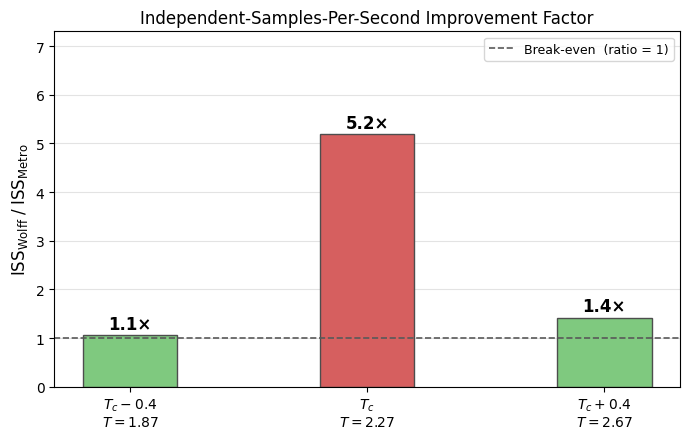

In [ ]:
t_targets  = [TC_ISING - 0.4, TC_ISING, TC_ISING + 0.4]
bar_labels = [
    f'$T_c - 0.4$\n$T = {t_targets[0]:.2f}$',
    f'$T_c$\n$T = {t_targets[1]:.2f}$',
    f'$T_c + 0.4$\n$T = {t_targets[2]:.2f}$',
]
bar_colors = ['#7fc97f', PALETTE['wolff'], '#7fc97f']

improvement = []
for Tt in t_targets:
    idx = int(np.argmin(np.abs(temperatures - Tt)))
    im = iss_metro[idx]
    iw = iss_wolff[idx]
    ratio = (iw / im) if (np.isfinite(im) and np.isfinite(iw) and im > 0) else float('nan')
    improvement.append(ratio)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(bar_labels, improvement, color=bar_colors, width=0.4, zorder=2, edgecolor='0.3')
ax.axhline(1.0, color='0.35', ls='--', lw=1.2, label='Break-even  (ratio = 1)')
ax.set_ylabel(
    r'$\mathrm{ISS}_{\mathrm{Wolff}}\;/\;\mathrm{ISS}_{\mathrm{Metro}}$', fontsize=12,
)
ax.set_title('Independent-Samples-Per-Second Improvement Factor', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.35, zorder=0)

finite_vals = [v for v in improvement if np.isfinite(v)]
if finite_vals:
    ax.set_ylim(0, max(finite_vals) * 1.35 + 0.3)

for bar, val in zip(bars, improvement):
    if np.isfinite(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.1f}×',
            ha='center', va='bottom', fontsize=12, fontweight='bold',
        )

fig.tight_layout()
plt.show()

## When to use Wolff

The results above translate directly into the algorithm selection rule documented in `AGENTS.md`. For any equilibrium study targeting a temperature range within roughly 20% of $T_c$ — for instance, a finite-size scaling analysis of the susceptibility peak, a determination of the critical exponent $\nu$, or a measurement of the Binder cumulant crossing — use `update='wolff'`. The improvement in $\tau_{\mathrm{int}}$ propagates through to a proportional reduction in statistical error for a fixed wall-clock budget, because the error on a time-averaged observable scales as $(2\tau_{\mathrm{int}} / N_{\mathrm{meas}})^{1/2}$.

For temperatures well away from $T_c$, checkerboard Metropolis (`update='checkerboard'`) is the correct default. The vectorised kernel saturates SIMD throughput and clusters are either too small or too large for Wolff to exploit. The crossover temperature — where the ISS curves intersect — is visible in the top-right panel and will shift closer to $T_c$ as $L$ increases, because critical slowing down intensifies with system size while Wolff's cluster-size advantage grows commensurately.

Neither algorithm should be used for kinetics studies. Both are equilibrium samplers without physical time evolution. Non-equilibrium quench and domain-growth measurements require `update='random'` (single-site random selection) to preserve the correct Glauber dynamics.

For the theoretical background — the FK representation, the Wolff-Evertz reflection construction for continuous spins, and the derivation of $P_{\mathrm{add}}$ — see `PHYSICS.md`.


## Bibliography

[[1]](#Bibliography) W. K. Hastings, "Monte Carlo sampling methods using Markov chains and their applications," *Biometrika*, vol. 57, no. 1, pp. 97–109, 1970. [Oxford Academic](https://academic.oup.com/biomet/article/57/1/97/252073)

[[2]](#Bibliography) U. Wolff, "Collective Monte Carlo Updating for Spin Systems," *Physical Review Letters*, vol. 62, no. 4, pp. 361–364, 1989. [APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361)

[[3]](#Bibliography) C. M. Fortuin and P. W. Kasteleyn, "On the random-cluster model. I. Introduction and relation to other models," *Physica*, vol. 57, no. 4, pp. 536–564, 1972. [Elsevier Open Access](https://doi.org/10.1016/0031-8914(72)90045-6)

[[4]](#Bibliography) M. E. J. Newman and G. T. Barkema, "Monte Carlo Methods in Statistical Physics," Oxford University Press, 1999. [Lecture Notes Summary (H. G. Katzgraber)](https://arxiv.org/abs/0905.1629)

